In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
from torch_geometric.transforms import NormalizeFeatures
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Датасет

In [4]:
dataset = Planetoid(
    root='data/Cora',
    name='Cora',
    transform=NormalizeFeatures()
)

data = dataset[0]

print(f'Количество узлов: {data.num_nodes}')
print(f'Количество рёбер: {data.num_edges}')
print(f'Количество признаков на узел: {dataset.num_node_features}')
print(f'Количество классов: {dataset.num_classes}')

Processing...
D:\дз\нейронки\Transformers\venv\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
D:\дз\нейронки\Transformers\venv\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
D:\дз\нейронки\Transformers\venv\Lib\site-packages\torch_geometric\io\planetoid.py:107: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  out = pickle.load(f, encoding='latin1')
D:\дз\нейронки\Transformers\venv\Lib\site-pa

Количество узлов: 2708
Количество рёбер: 10556
Количество признаков на узел: 1433
Количество классов: 7


Done!


Проверка сбалансированности классов в датасете

In [10]:
train_labels = data.y[data.train_mask]
train_counts = torch.bincount(train_labels)

print("\nTrain распределение:")
for i, count in enumerate(train_counts):
    print(f"Класс {i}: {count.item()}")

test_labels = data.y[data.test_mask]
test_counts = torch.bincount(test_labels)

print("\nTest распределение:")
for i, count in enumerate(test_counts):
    print(f"Класс {i}: {count.item()}")


Train распределение:
Класс 0: 20
Класс 1: 20
Класс 2: 20
Класс 3: 20
Класс 4: 20
Класс 5: 20
Класс 6: 20

Test распределение:
Класс 0: 130
Класс 1: 91
Класс 2: 144
Класс 3: 319
Класс 4: 149
Класс 5: 103
Класс 6: 64


Определение модели

In [5]:
class GCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()

        # Первый графовый сверточный слой
        self.conv1 = GCNConv(in_channels, hidden_channels)

        # Второй графовый сверточный слой
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # Первый слой
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        # Второй слой
        x = self.conv2(x, edge_index)

        return x

Инициализация модели

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(
    in_channels=dataset.num_node_features,
    hidden_channels=16,
    out_channels=dataset.num_classes
).to(device)

data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

Обучение

In [7]:
def train():
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)

    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    return loss.item()

Тестирование

In [8]:
def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    correct = pred[data.test_mask] == data.y[data.test_mask]
    acc = int(correct.sum()) / int(data.test_mask.sum())
    return acc

Запуск обучения

In [12]:
losses = []

for epoch in range(1, 201):
    loss = train()
    losses.append(loss)
    if epoch % 20 == 0:
        acc = test()
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Test Acc: {acc:.4f}')

print("Финальная точность:", test())

Epoch: 020, Loss: 0.1933, Test Acc: 0.8170
Epoch: 040, Loss: 0.1826, Test Acc: 0.8160
Epoch: 060, Loss: 0.1737, Test Acc: 0.8170
Epoch: 080, Loss: 0.1664, Test Acc: 0.8170
Epoch: 100, Loss: 0.1601, Test Acc: 0.8160
Epoch: 120, Loss: 0.1547, Test Acc: 0.8130
Epoch: 140, Loss: 0.1501, Test Acc: 0.8130
Epoch: 160, Loss: 0.1460, Test Acc: 0.8120
Epoch: 180, Loss: 0.1425, Test Acc: 0.8110
Epoch: 200, Loss: 0.1394, Test Acc: 0.8100
Финальная точность: 0.81


Оценка результатов классификации

In [15]:
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

# Берём только test узлы
y_true = data.y[data.test_mask].cpu().numpy()
y_pred = pred[data.test_mask].cpu().numpy()

# Метрики
accuracy = accuracy_score(y_true, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred)


Accuracy: 0.81

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.78      0.72       130
           1       0.77      0.86      0.81        91
           2       0.88      0.85      0.87       144
           3       0.90      0.78      0.84       319
           4       0.78      0.87      0.82       149
           5       0.85      0.76      0.80       103
           6       0.70      0.81      0.75        64

    accuracy                           0.81      1000
   macro avg       0.79      0.82      0.80      1000
weighted avg       0.82      0.81      0.81      1000



Визуализация

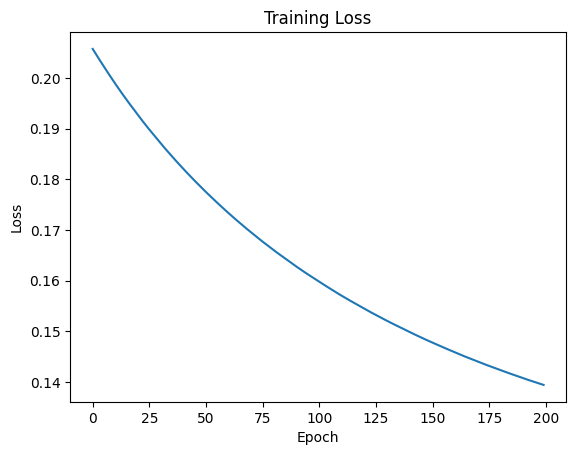

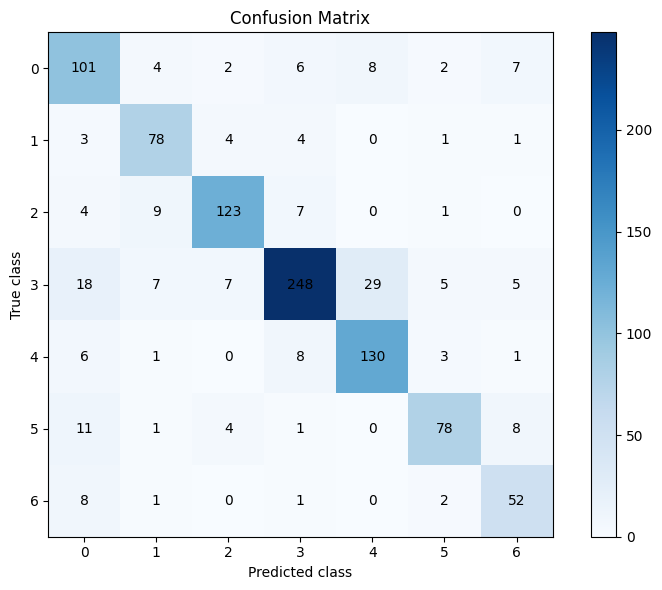

In [16]:
plt.figure()
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")  # спокойная цветовая схема
plt.title("Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()

# Добавляем числа в ячейки
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            cm[i, j],
            ha="center",
            va="center",
            color="black"
        )

plt.xticks(np.arange(cm.shape[0]))
plt.yticks(np.arange(cm.shape[0]))
plt.tight_layout()
plt.show()